## Notebook 3 for clustering processing

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os

from tqdm import tqdm

import hdbscan

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, silhouette_score, accuracy_score, confusion_matrix#, calinski_harabasz_score, davies_bouldin_score

from sklearn.manifold import TSNE

from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier

import plotly.express as px
import plotly.graph_objects as go

In [10]:
# import the merged data file
merged_df = pd.read_csv('fusion_results_merged.csv.gzip', compression='gzip', sep=',', header=0, dtype={'# sample': str, 'Depth': str})
merged_df.head()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,U,Sum,Filename,Core,# sample,Depth,Conductivity,# Non-soluble dust,d18O,dD
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,12198.0950,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2397.7219,0.0,0.0,...,0.0,2397.7219,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7130.3062,0.0,0.0,...,0.0,7130.3062,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41294.3340,0.0,0.0,...,0.0,41294.3340,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,21668.7410,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557


In [11]:
# convert all masses in moles adding a new column per element
# all elements are in ag and molar mass are in g/mol in the table named 'Molar mass.csv'
molar_mass = pd.read_csv('Molar mass.csv', index_col=0, sep=';')
molar_mass

,MolarMass_g_per_mol
Element,
Al,26.982
Sb,121.760
Ar,39.950
As,74.922
Ba,137.330
...,...
Xe,131.290
Yb,173.050
Y,88.906


In [12]:
# calculate elemental fraction for all except NP #, Sum, Layer, and Mask
elements = []
for col in merged_df.columns:
    if col not in ['Au', 'Sum', 'Filename', 'Core', '# sample', 'Depth', 'Conductivity', '# Non-soluble dust', 'd18O', 'dD']:
        merged_df[f'{col} moles'] = merged_df[col] / (molar_mass.loc[col, 'MolarMass_g_per_mol'] * 1e18)  # convert g/mol to ag/mol
        elements.append(col)

merged_df['Sum moles'] = merged_df[[f'{col} moles' for col in elements]].sum(axis=1)  # Corrected sum calculation

# calculate the moles and mass fraction for each element
for col in elements:
    merged_df[f'{col} mole fraction'] = merged_df[f'{col} moles'] / merged_df['Sum moles']

# remove Au column as it is not needed for clustering
merged_df.drop(columns='Au', inplace=True)
# remove all rows with NaN values
merged_df.dropna(inplace=True)

# save the element list to a file
with open('elements.txt', 'w') as f:
    for element in elements:
        f.write(f"{element}\n")

merged_df

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction
1,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,2397.7219,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,7130.3062,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,41294.3340,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
11,0.0,0.000,0.0,0.0,0.0,3783.7901,0.00000,0.0000,0.0,0.0,...,0.941822,0.000000,0.000000,0.0,0.0,0.0,0.0,0.014665,0.043513,0.0
15,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,2540.5517,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574575,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,96627.8250,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1574579,0.0,0.000,0.0,0.0,0.0,0.0000,414.62018,22893.7490,0.0,0.0,...,0.000000,0.018077,0.981923,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1574580,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,4444.0267,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1574584,0.0,0.000,0.0,0.0,0.0,0.0000,0.00000,5372.2137,0.0,0.0,...,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


In [13]:
merged_df.describe()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction
count,4.788850e+05,4.788850e+05,4.788850e+05,478885.000000,4.788850e+05,4.788850e+05,478885.000000,4.788850e+05,478885.000000,478885.000000,...,478885.000000,478885.000000,478885.000000,478885.000000,478885.000000,478885.000000,478885.000000,478885.000000,478885.000000,478885.000000
mean,7.506998e+02,5.017203e+03,1.511698e+04,1079.539839,8.237612e+02,7.769296e+02,37.168466,6.259549e+03,4.403161,5.910575,...,0.056917,0.002969,0.515244,0.001531,0.002150,0.003543,0.003015,0.005530,0.003023,0.000880
std,1.264302e+04,2.665609e+04,5.698902e+04,8018.325847,8.038001e+03,1.102252e+04,614.170286,2.895568e+04,84.932933,259.971691,...,0.223927,0.052329,0.473967,0.039040,0.045086,0.058832,0.053683,0.072222,0.051933,0.028770
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.585096
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,1.160614e+03,0.000000,0.000000,...,0.000000,0.000000,0.424202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000e+00,0.000000e+00,9.713533e+03,0.000000,0.000000e+00,0.000000e+00,0.000000,3.431068e+03,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.086095e+06,2.040532e+06,2.894823e+06,778435.500000,1.151319e+06,2.465223e+06,138633.630000,2.364965e+06,24427.793000,76160.239000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# Prepapre the data for clustering
# drop all except columns ending with fraction
X_clust = merged_df.filter(like='mole fraction').copy()

# Take only a part of the data for clustering
#n = 100000  # number of samples to take
X_clust_scaled = X_clust#.sample(n, random_state=42)
X_clust_scaled

,Mg mole fraction,Al mole fraction,Si mole fraction,K mole fraction,Ca mole fraction,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
11,0.0,0.0,0.0,0.0,0.0,0.941822,0.000000,0.000000,0.0,0.0,0.0,0.0,0.014665,0.043513,0.0
15,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574575,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1574579,0.0,0.0,0.0,0.0,0.0,0.000000,0.018077,0.981923,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1574580,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1574584,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


Accuracy of the Random Forest classifier: 1.00


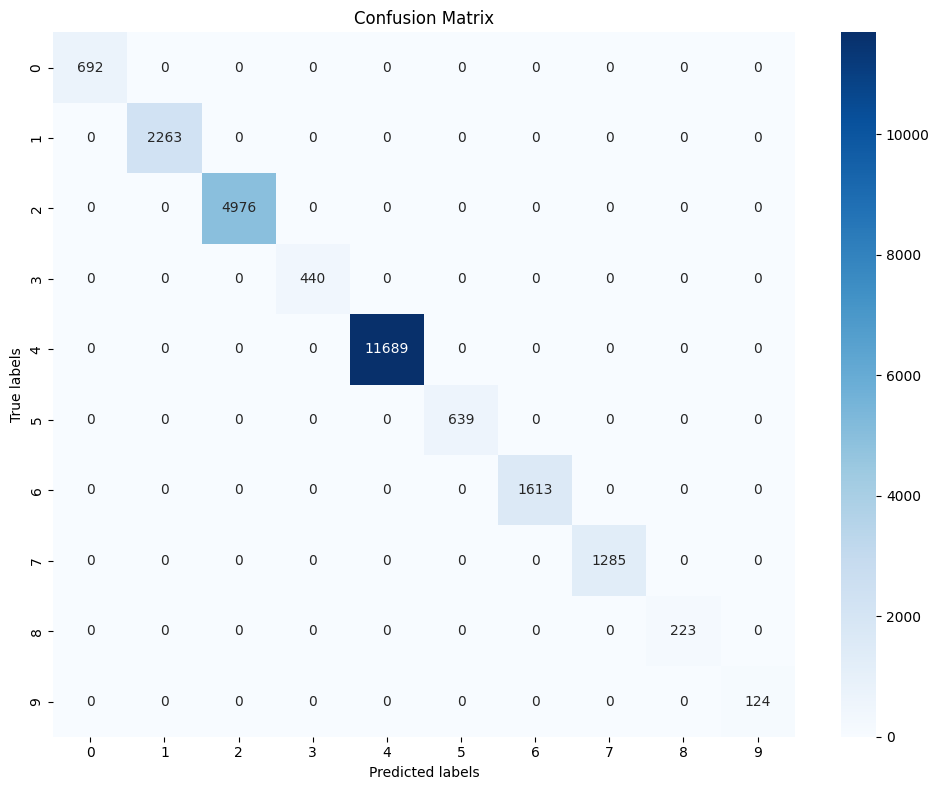

In [15]:
# Sample
subset = X_clust_scaled.sample(n=len(X_clust_scaled) // 20, random_state=42)
X_sub = subset.values

# Agglomerative clustering
labels = AgglomerativeClustering(n_clusters=10).fit_predict(X_sub)

# Train a classifier
clf = RandomForestClassifier()
clf.fit(X_sub, labels)

# evaluate the accuracy of the Random Forest classifier
accuracy = accuracy_score(labels, clf.predict(X_sub))
print(f"Accuracy of the Random Forest classifier: {accuracy:.2f}")

# plot the confusion matrix
cm = confusion_matrix(labels, clf.predict(X_sub))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.tight_layout()


In [16]:
# Predict on the rest of the data
X_full = X_clust_scaled.values
predicted_labels = clf.predict(X_full)

# Add the predicted labels to the original DataFrame
merged_df['Agglomerative Cluster'] = predicted_labels

# Save the DataFrame with clusters
merged_df.to_csv('fusion_results_merged_with_clusters.csv.gzip', index=False, compression='gzip')